In [1]:
import os, glob, random, shutil, time
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models   
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
DATASET_DIR = "folder/UFPR-ALPR dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "training")
TEST_DIR = os.path.join(DATASET_DIR, "testing")

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((100, 200)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()

])

val_tf = transforms.Compose([
    transforms.Resize((100, 200)),
    transforms.ToTensor()
])

print("Imports and setup done. Device:", DEVICE)

Imports and setup done. Device: cuda


In [5]:
class BiasAwareSampler:
    def __init__(self, classes, smoothing=1.0):
        self.classes = classes
        self.smoothing = smoothing
        self.counts = defaultdict(float)
        for cls in classes:
            self.counts[cls] = smoothing   # every class starts equal

    def sample_negative_class(self, exclude_class):
        candidates = [c for c in self.classes if c != exclude_class]
        counts     = np.array([self.counts[c] for c in candidates], dtype=np.float64)
        weights    = 1.0 / counts          # rare classes get higher weight
        weights   /= weights.sum()         # make it a valid probability distribution
        chosen     = np.random.choice(candidates, p=weights)
        self.counts[chosen] += 1.0         # update count so it adjusts next time
        return chosen

    def get_imbalance_ratio(self):
        counts = list(self.counts.values())
        return max(counts) / min(counts)   # 1.0 = perfectly balanced


class PlatePairsDataset(Dataset):
    def __init__(self, root_dir, transform=None, seed=42):
        self.root_dir  = root_dir
        self.transform = transform
        random.seed(seed)
        np.random.seed(seed)

        self.class_to_imgs = {}
        self.image_list    = []

        for cls in sorted(os.listdir(root_dir)):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            imgs = [os.path.join(cls_path, f)
                    for f in os.listdir(cls_path)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
            if len(imgs) >= 2:
                self.class_to_imgs[cls] = imgs
                self.image_list.extend([(cls, p) for p in imgs])

        self.classes = list(self.class_to_imgs.keys())
        if len(self.classes) < 2:
            raise ValueError("Need at least 2 classes with >=2 images each.")

        # This is the new line — creates the sampler attached to this dataset
        self.sampler = BiasAwareSampler(self.classes, smoothing=1.0)
        print(f"[BiasAware] {len(self.classes)} classes | {len(self.image_list)} images")

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        cls1, img1_path = self.image_list[idx]
        label = random.randint(0, 1)

        if label == 1:
            # Positive pair — same plate, different photo
            img2_path = random.choice([p for p in self.class_to_imgs[cls1]
                                       if p != img1_path])
        else:
            # Negative pair — THIS LINE is the key change
            # Old code: cls2 = random.choice(candidate_classes)
            # New code: uses inverse-frequency weights via the sampler
            cls2      = self.sampler.sample_negative_class(exclude_class=cls1)
            img2_path = random.choice(self.class_to_imgs[cls2])

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

    def get_imbalance_ratio(self):
        return self.sampler.get_imbalance_ratio()

In [6]:
class SiameseNet(nn.Module):
    """
    Siamese Network using ResNet18 backbone.
    Outputs L2-normalized embeddings for contrastive learning.
    """
    def __init__(self, embedding_dim=128):
        super().__init__()
        # ResNet18 backbone
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        base.fc = nn.Identity()  # Remove classification layer
        self.backbone = base

        # Projection head
        self.proj = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),  # optional but stabilizes training
            nn.Linear(256, embedding_dim)
        )

    def forward_once(self, x):
        feat = self.backbone(x)
        emb = self.proj(feat)
        emb = F.normalize(emb, p=2, dim=1)  # L2-normalize embeddings
        return emb

    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)


# Instantiate model
model = SiameseNet(embedding_dim=128).to(DEVICE)
print("Model ready on device:", DEVICE)

Model ready on device: cuda


In [7]:
import torch.nn.functional as F

class ContrastiveLoss(nn.Module):
    """
    Contrastive loss with Online Hard Negative Mining.
    
    For positive pairs: penalizes large embedding distances.
    For negative pairs: 
        - Hard negatives (similarity > hard_neg_threshold) get up-weighted
          by hard_neg_weight, forcing the model to focus on confusing pairs.
        - Easy negatives contribute normally.
    
    This replaces the original equal-weight contrastive loss.
    """
    def __init__(self, margin=1.0, hard_neg_threshold=0.5, hard_neg_weight=2.0):
        super().__init__()
        self.margin             = margin
        self.hard_neg_threshold = hard_neg_threshold  # similarity above this = hard negative
        self.hard_neg_weight    = hard_neg_weight      # how much extra to penalize hard negs
        self.hard_neg_count     = 0                    # tracked for logging

    def forward(self, emb1, emb2, label):
        # --- Step 1: Compute distances and similarities ---
        dist    = F.pairwise_distance(emb1, emb2)
        sim     = F.cosine_similarity(emb1, emb2)   # higher = more similar

        # --- Step 2: Positive pair loss (unchanged) ---
        pos_loss = label * torch.pow(dist, 2)

        # --- Step 3: Identify hard negatives ---
        is_negative  = (label == 0)                          # mask for negative pairs
        is_hard      = (sim > self.hard_neg_threshold)       # model thinks they look alike
        is_hard_neg  = is_negative & is_hard                 # both conditions = hard negative

        # Track count for logging
        self.hard_neg_count = int(is_hard_neg.sum().item())

        # --- Step 4: Build per-sample weights ---
        # Start with weight=1 for everyone
        weights = torch.ones_like(label)
        # Up-weight hard negatives
        weights[is_hard_neg] = self.hard_neg_weight

        # --- Step 5: Negative pair loss with weights applied ---
        neg_loss = (1 - label) * torch.pow(
            torch.clamp(self.margin - dist, min=0.0), 2
        )
        weighted_neg_loss = weights * neg_loss

        # --- Step 6: Combine and return mean loss ---
        loss = torch.mean(pos_loss + weighted_neg_loss)
        return loss

In [8]:
# Recreate dataset if not defined
if 'full_dataset' not in globals():
    full_dataset = PlatePairsDataset(TRAIN_DIR, transform=train_tf)

[BiasAware] 60 classes | 1800 images


In [9]:
# Ensure model exists
if 'model' not in globals():
    model = SiameseNet(embedding_dim=128).to(DEVICE)
    print("Model initialized")

In [10]:
# --- Training helper functions ---
import time
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from torch.optim.lr_scheduler import StepLR

# --- FIX: Split by class instead of image ---

from torch.utils.data import Subset

# Get all classes
all_classes = list(full_dataset.class_to_imgs.keys())
random.shuffle(all_classes)

# Split classes
split_idx = int(0.8 * len(all_classes))
train_classes = all_classes[:split_idx]
val_classes = all_classes[split_idx:]

# Filter indices for each split
train_indices = [i for i, (cls, _) in enumerate(full_dataset.image_list) if cls in train_classes]
val_indices   = [i for i, (cls, _) in enumerate(full_dataset.image_list) if cls in val_classes]

# Create subsets
train_ds = Subset(full_dataset, train_indices)
val_ds   = Subset(full_dataset, val_indices)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print("Train classes:", len(train_classes), "Val classes:", len(val_classes))
print("Train samples:", len(train_ds), "Val samples:", len(val_ds))

# --- TEST DATASET ---
test_dataset = PlatePairsDataset(TEST_DIR, transform=val_tf)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test samples:", len(test_dataset))

# --- Helper functions ---
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    running_loss = 0.0
    for x1, x2, y in tqdm(loader, desc="Training", leave=False):
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        optimizer.zero_grad()
        e1, e2 = model(x1, x2)
        loss = criterion(e1, e2, y)  
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

def evaluate(model, loader, device=DEVICE):
    model.eval()
    all_labels, all_scores = [], []

    with torch.no_grad():
        for x1, x2, y in loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)

            e1, e2 = model(x1, x2)

            # Use cosine similarity (higher = more similar)
            sim = F.cosine_similarity(e1, e2)

            all_scores.extend(sim.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)

    # For cosine similarity → higher = positive class
    roc_auc = roc_auc_score(all_labels, all_scores)

    return roc_auc, all_labels, all_scores

# --- Training setup ---
EPOCHS       = 10
criterion    = ContrastiveLoss(margin=1.0)
optimizer    = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler    = StepLR(optimizer, step_size=5, gamma=0.5)

best_auc     = -1
train_losses = []   
val_aucs     = []   


MODELS_DIR = "./models"      
best_path  = os.path.join(MODELS_DIR, "best_model.pth")   

os.makedirs(MODELS_DIR, exist_ok=True)
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    scheduler.step()
    auc, y_true, y_score = evaluate(model, val_loader)

    train_losses.append(loss)   # ← FIX: this line was missing
    val_aucs.append(auc)        # ← FIX: this line was missing

    imbalance = full_dataset.get_imbalance_ratio()

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Loss: {loss:.4f} | "
          f"Val AUC: {auc:.4f} | "
          f"Imbalance: {imbalance:.2f}x | "
          f"Hard negs: {criterion.hard_neg_count}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), best_path)

print(f"\nBest Val ROC-AUC : {best_auc:.4f}")
print(f"Training time    : {round((time.time() - start_time) / 60, 2)} min")
print(f"Final imbalance  : {full_dataset.get_imbalance_ratio():.2f}x")

print("Best Val ROC-AUC:", best_auc)
print("Saved best model to:", best_path)
print("Training time (minutes):", round((time.time() - start_time) / 60, 2))

Train classes: 48 Val classes: 12
Train samples: 1440 Val samples: 360
[BiasAware] 60 classes | 1800 images
Test samples: 1800


Epoch 01/10 | Loss: 0.3034 | Val AUC: 0.9062 | Imbalance: 1.00x | Hard negs: 1


Epoch 02/10 | Loss: 0.1092 | Val AUC: 0.9759 | Imbalance: 1.00x | Hard negs: 1


Epoch 03/10 | Loss: 0.0793 | Val AUC: 0.9869 | Imbalance: 1.00x | Hard negs: 0


Epoch 04/10 | Loss: 0.0697 | Val AUC: 0.9896 | Imbalance: 1.00x | Hard negs: 2


...

Epoch 06/10 | Loss: 0.0622 | Val AUC: 0.9909 | Imbalance: 1.00x | Hard negs: 1


Epoch 07/10 | Loss: 0.0570 | Val AUC: 0.9926 | Imbalance: 1.00x | Hard negs: 0


Epoch 08/10 | Loss: 0.0535 | Val AUC: 0.9976 | Imbalance: 1.00x | Hard negs: 1


Epoch 09/10 | Loss: 0.0526 | Val AUC: 0.9968 | Imbalance: 1.00x | Hard negs: 1


Epoch 10/10 | Loss: 0.0497 | Val AUC: 0.9920 | Imbalance: 1.00x | Hard negs: 0

Best Val ROC-AUC : 0.9976
Training time    : 8.74 min
Final imbalance  : 1.00x
Best Val ROC-AUC: 0.9976227964558056
Saved best model to: ./models/best_model.pth
Training time (minutes): 8.74


In [11]:
from sklearn.metrics import roc_curve
import numpy as np

# Run evaluation on validation set AGAIN (for threshold)
model.load_state_dict(torch.load(best_path))
model.eval()

all_labels, all_scores = [], []

with torch.no_grad():
    for x1, x2, y in val_loader:
        x1, x2, y = x1.to(DEVICE), x2.to(DEVICE), y.to(DEVICE)

        e1, e2 = model(x1, x2)
        sim = F.cosine_similarity(e1, e2)

        all_scores.extend(sim.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

# Compute threshold
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print("Best threshold (VAL):", best_threshold)

/tmp/ipykernel_3072706/2940824730.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path))


Best threshold (VAL): 0.7198821


In [12]:
# --- FINAL TEST EVALUATION ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model.load_state_dict(torch.load(best_path))
model.eval()

all_labels = []
all_scores = []

with torch.no_grad():
    for x1, x2, y in test_loader:
        x1, x2, y = x1.to(DEVICE), x2.to(DEVICE), y.to(DEVICE)

        e1, e2 = model(x1, x2)
        sim = F.cosine_similarity(e1, e2)

        all_scores.extend(sim.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

preds = (all_scores >= best_threshold).astype(int)

accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
f1 = f1_score(all_labels, preds)
roc_auc = roc_auc_score(all_labels, all_scores)

print("\n--- TEST RESULTS ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

/tmp/ipykernel_3072706/3971811981.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path))



--- TEST RESULTS ---
Accuracy:  0.9478
Precision: 0.9127
Recall:    0.9862
F1-score:  0.9480
ROC-AUC:   0.9930


/tmp/ipykernel_3072706/3665044435.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path))


Running t-SNE... (this takes ~1-2 minutes)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3600 samples in 0.016s...
[t-SNE] Computed neighbors for 3600 samples in 0.594s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3600
[t-SNE] Computed conditional probabilities for sample 2000 / 3600
[t-SNE] Computed conditional probabilities for sample 3000 / 3600
[t-SNE] Computed conditional probabilities for sample 3600 / 3600
[t-SNE] Mean sigma: 0.114952
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.213661
[t-SNE] KL divergence after 1000 iterations: 0.141292
t-SNE done.


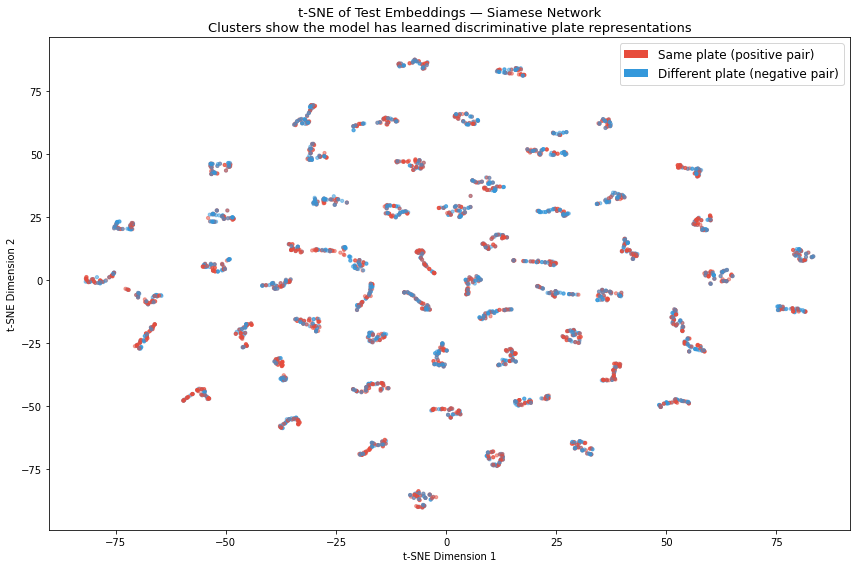

Saved t-SNE plot to: /home/fmalik5/Documents/COSC880/Progress/Images/tsne_20260714_020805.png


In [13]:
# ============================================================
# t-SNE VISUALIZATION OF TEST EMBEDDINGS
# ============================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from datetime import datetime


# --- Step 1: Extract embeddings from test set ---
model.load_state_dict(torch.load(best_path))
model.eval()

all_embeddings = []
all_labels_tsne = []

with torch.no_grad():
    for x1, x2, y in test_loader:
        x1 = x1.to(DEVICE)
        x2 = x2.to(DEVICE)

        e1, e2 = model(x1, x2)

        # Collect both images from each pair with their class info
        all_embeddings.append(e1.cpu().numpy())
        all_embeddings.append(e2.cpu().numpy())

        # y=1 means same class — we just need any label for coloring
        # so we use the pair index as a proxy class ID
        all_labels_tsne.extend([int(y[i].item()) for i in range(len(y))])
        all_labels_tsne.extend([int(y[i].item()) for i in range(len(y))])

all_embeddings = np.vstack(all_embeddings)

# --- Step 2: Run t-SNE ---
print("Running t-SNE... (this takes ~1-2 minutes)")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    verbose=1
)
embeddings_2d = tsne.fit_transform(all_embeddings)
print("t-SNE done.")

# --- Step 3: Plot ---
plt.figure(figsize=(12, 8))

# Color by label: 1=same pair (positive), 0=different pair (negative)
colors = ['#e74c3c' if l == 1 else '#3498db' for l in all_labels_tsne]

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=colors,
    alpha=0.5,
    s=10
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Same plate (positive pair)'),
    Patch(facecolor='#3498db', label='Different plate (negative pair)')
]
plt.legend(handles=legend_elements, fontsize=12)

plt.title('t-SNE of Test Embeddings — Siamese Network\n'
          'Clusters show the model has learned discriminative plate representations',
          fontsize=13)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()

# Save it
SAVE_DIR = "/home/fmalik5/Documents/COSC880/Progress/Images"
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
tsne_path = os.path.join(SAVE_DIR, f"tsne_{timestamp}.png")
plt.savefig(tsne_path, dpi=150)
plt.show()
print(f"Saved t-SNE plot to: {tsne_path}")

In [14]:
SAVE_DIR = "/home/fmalik5/Documents/COSC880/Progress/Images"
os.makedirs(SAVE_DIR, exist_ok=True)

In [15]:
import matplotlib.pyplot as plt
from datetime import datetime
import os

plt.figure()
plt.plot(fpr, tpr, label='ROC Curve')  # just use label
plt.plot([0, 1], [0, 1], 'k--', label='Random')  # dashed diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_path = os.path.join(SAVE_DIR, f"roc_curve_{timestamp}.png")

plt.savefig(plot_path)
plt.close()
print(f"Saved ROC curve: {plot_path}")

Saved ROC curve: /home/fmalik5/Documents/COSC880/Progress/Images/roc_curve_20260714_020830.png


In [16]:
# --- Save model progress at the end ---

SAVE_DIR = "/home/fmalik5/Documents/COSC880/Progress/Images"
os.makedirs(SAVE_DIR, exist_ok=True)

# Add timestamp to filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"siamese_model_{timestamp}.pth"
save_path = os.path.join(SAVE_DIR, filename)

# Save model state
torch.save(model.state_dict(), save_path)

print(f"Model saved successfully as {filename}")

Model saved successfully as siamese_model_20260714_020837.pth


In [17]:
torch.save(model.state_dict(), "best_model.pth")
print("Model saved!")

Model saved!
